# Analphabethismus in kriegsbetroffenen Ländern

## Gruppe: 
Lia Bütikofer (buetilia@students.zhaw.ch), Vanessa Cakoncev (cakonvan@students.zhaw.ch), Lilia Totila (totillil@students.zhaw.ch)

## Fragestellung
Wie hat sich das BIP-Analphabethismus Verhältnis in kriegsbetroffenen Ländern (Afghanistan, Sudan, Syrien und Irak) von 1990 bis 2023 verändert?

## Quellen
https://ourworldindata.org/grapher/literacy-rate-vs-gdp-per-capita


## 1. Daten beschaffen und laden

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# URL zur Our-World-in-Data CSV (Alphabetisierung vs. BIP pro Kopf)
url = "https://ourworldindata.org/grapher/literacy-rate-vs-gdp-per-capita.csv"

# CSV von der URL einlesen
file_name = "literacy-rate-vs-gdp-per-capita.csv"
df = pd.read_csv(file_name)

# ersten Eindruck bekommen
df.head()

,Entity,Code,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical),World regions according to OWID
0,Afghanistan,AFG,1979,18.00000,NaN,13655575.0,NaN
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN


## 2. Daten vorbereiten 
- Die Roh-Daten sind bereits im Long-Format
- Für die Analyse werden die Daten pivotiert: Jede Spalte repräsentiert eine Region, die Zeilen sind die verschiedenen Jahre - in absteigender Reihenfolge.

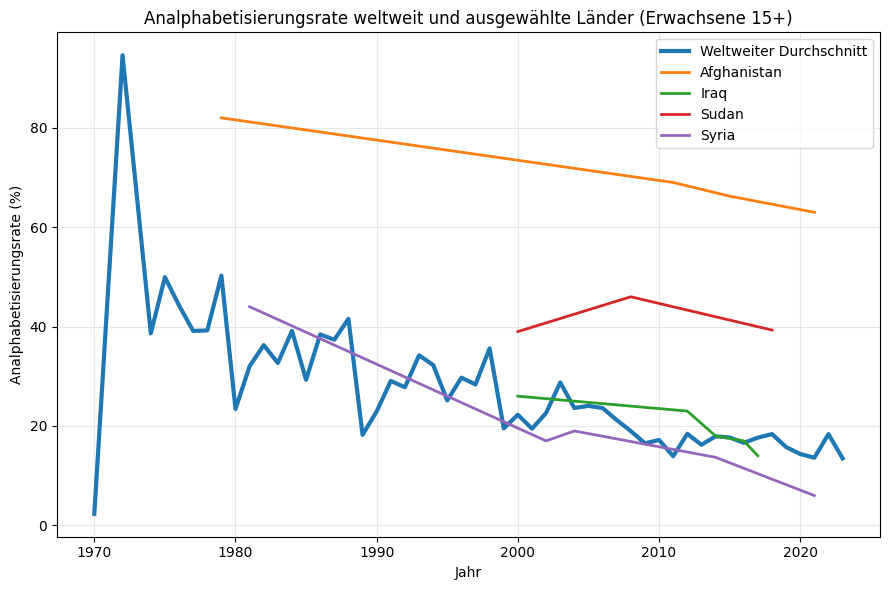

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV-Datei laden
df = pd.read_csv("literacy-rate-adults.csv")

lit_col = "Literacy rate, adult total (% of people ages 15 and above)"
countries = ["Afghanistan", "Iraq", "Sudan", "Syria"]

# Weltweiter Durchschnitt pro Jahr
world = (
    df.groupby("Year")[lit_col]
    .mean()
    .reset_index()
)
world["Illiteracy"] = 100 - world[lit_col]

# Länderlinien vorbereiten
country_lines = {}
for c in countries:
    cdf = df[df["Entity"] == c].copy()
    cdf["Illiteracy"] = 100 - cdf[lit_col]
    country_lines[c] = cdf[["Year", "Illiteracy"]]

# Plot
plt.figure(figsize=(9, 6))

# Weltlinie
plt.plot(
    world["Year"],
    world["Illiteracy"],
    linewidth=3,
    label="Weltweiter Durchschnitt"
)

# Länderlinien
for c, cdf in country_lines.items():
    plt.plot(
        cdf["Year"],
        cdf["Illiteracy"],
        linewidth=2,
        label=c
    )

plt.xlabel("Jahr")
plt.ylabel("Analphabetisierungsrate (%)")
plt.title("Analphabetisierungsrate weltweit und ausgewählte Länder (Erwachsene 15+)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
import pandas as pd
import numpy as np

def generate_combined_table(file_path):
    """
    Erstellt eine formatierte, pivotierte Tabelle mit BIP und Alphabetisierungsrate 
    für vier spezifische Länder im Zeitraum 1990-2023.
    """
    
    # 1. Parameter definieren
    target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq']
    start_year = 1990
    end_year = 2023
    gdp_column = 'GDP per capita, PPP (constant 2021 international $)'
    literacy_column = 'Literacy rate among adults'

    # 2. Daten laden und filtern
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Fehler: Datei '{file_path}' nicht gefunden.")
        return None

    df_filtered = df[df['Entity'].isin(target_countries)].copy()
    df_filtered['Year'] = pd.to_numeric(df_filtered['Year'], errors='coerce')

    df_plot = df_filtered[
        (df_filtered['Year'] >= start_year) & (df_filtered['Year'] <= end_year)
    ].copy()

    # 3. Spalten auswählen und umbenennen
    df_selected = df_plot[['Entity', 'Year', gdp_column, literacy_column]].copy()
    df_selected.rename(columns={
        'Entity': 'Land',
        'Year': 'Jahr',
        gdp_column: 'BIP ($)',
        literacy_column: 'Rate (%)'
    }, inplace=True)

    # 4. Aggregation (Mittelwert bei Duplikaten pro Land/Jahr)
    df_agg = df_selected.groupby(['Land', 'Jahr']).mean().reset_index()

    # 5. Daten pivotieren und neu ordnen (Jahr, Metrik)
    df_pivot = df_agg.pivot_table(index='Land', columns='Jahr', values=['BIP ($)', 'Rate (%)'])

    # Tausche die Ebenen (Metrik, Jahr) zu (Jahr, Metrik) und sortiere nach Jahr
    df_final = df_pivot.swaplevel(axis=1).sort_index(axis=1)
    df_final.columns.names = ['Jahr', 'Metrik']

    # 6. Formatierung für bessere Lesbarkeit
    def format_value(value, metric):
        if pd.isna(value):
            return '-'
        if metric == 'BIP ($)':
            # Runde auf die nächste Tausender-Zahl und verwende Tausender-Trenner (z.B. 1.234)
            return f"{int(round(value / 1000)):,}".replace(',', '.')
        elif metric == 'Rate (%)':
            # Runde auf eine Dezimalstelle
            return f"{value:.1f}"
        return str(value)

    # Erstelle einen leeren DataFrame für die formatierten Daten
    df_display = pd.DataFrame(index=df_final.index, columns=df_final.columns)

    # Wende die Formatierung auf jede Zelle an
    for (jahr, metric) in df_final.columns:
        df_display[(jahr, metric)] = df_final[(jahr, metric)].apply(lambda x: format_value(x, metric))

    # 7. Speichern der Tabelle (für CSV ist die Standard-MultiIndex-Darstellung am besten)
    output_file_csv = 'BIP_Analphabetisierung_uebersicht_final.csv'
    df_final.to_csv(output_file_csv, index=True)

    print(f"Tabelle gespeichert in: {output_file_csv}")
    print("\n--- Übersichtliche Tabelle ---")
    print(df_display.to_markdown())
    
    return df_display
plt.show()

# Ausführung der Funktion
# Stellen Sie sicher, dass 'literacy-rate-vs-gdp-per-capita.csv' im selben Verzeichnis liegt.
# generate_combined_table('literacy-rate-vs-gdp-per-capita.csv')

C:\Users\bueti\AppData\Local\Temp\ipykernel_16328\1882943074.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in df_latest.groupby("GDP_group"):


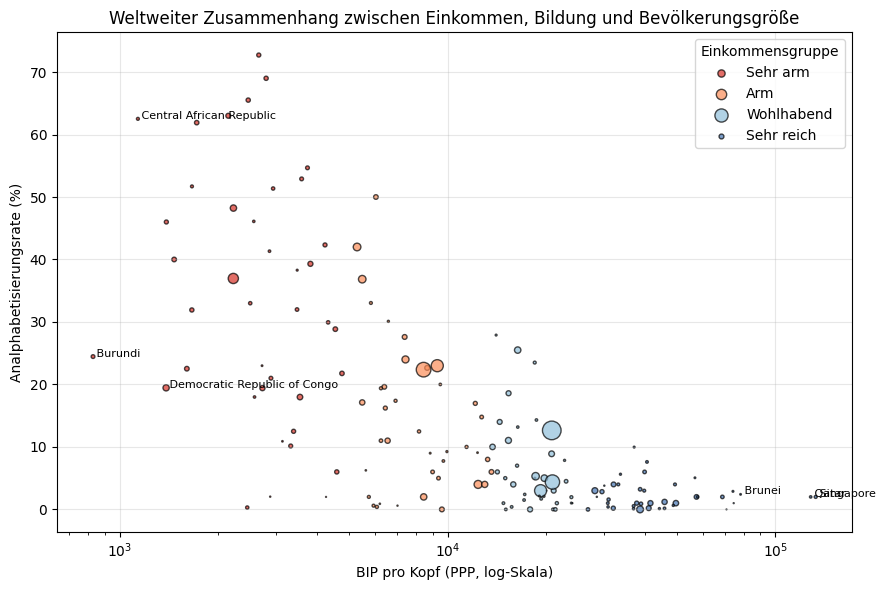

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

lit = pd.read_csv("literacy-rate-adults.csv")
gdp = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

lit_col = "Literacy rate, adult total (% of people ages 15 and above)"
gdp_col = "GDP per capita, PPP (constant 2021 international $)"
pop_col = "Population (historical)"

# Analphabetisierung
lit["Illiteracy"] = 100 - lit[lit_col]

df = (
    lit.merge(
        gdp[["Entity", "Year", gdp_col, pop_col]],
        on=["Entity", "Year"],
        how="inner"
    )
    .dropna(subset=[gdp_col, "Illiteracy", pop_col])
)

# Neuester Wert pro Land
df_latest = (
    df.sort_values("Year")
      .groupby("Entity", as_index=False)
      .tail(1)
)

# Einkommensgruppen
df_latest["GDP_group"] = pd.qcut(
    df_latest[gdp_col],
    q=4,
    labels=["Sehr arm", "Arm", "Wohlhabend", "Sehr reich"]
)

# Bubble-Größe (Bevölkerung)
sizes = np.sqrt(df_latest[pop_col]) / 500

# Farben
color_map = {
    "Sehr arm": "#d73027",
    "Arm": "#fc8d59",
    "Wohlhabend": "#91bfdb",
    "Sehr reich": "#4575b4"
}

plt.figure(figsize=(9,6))

for group, gdf in df_latest.groupby("GDP_group"):
    plt.scatter(
        gdf[gdp_col],
        gdf["Illiteracy"],
        s=sizes[gdf.index],
        alpha=0.7,
        label=group,
        color=color_map[group],
        edgecolor="black"
    )

plt.xscale("log")
plt.xlabel("BIP pro Kopf (PPP, log-Skala)")
plt.ylabel("Analphabetisierungsrate (%)")
plt.title("Weltweiter Zusammenhang zwischen Einkommen, Bildung und Bevölkerungsgröße")
plt.grid(True, alpha=0.3)
plt.legend(title="Einkommensgruppe")

# Extreme Länder beschriften
lowest = df_latest.nsmallest(3, gdp_col)
highest = df_latest.nlargest(3, gdp_col)
extremes = pd.concat([lowest, highest])

for _, r in extremes.iterrows():
    plt.text(r[gdp_col], r["Illiteracy"], f" {r['Entity']}", fontsize=8)

plt.tight_layout()
plt.show()

--- 1. Variablenanalyse (Kontinuierlich vs. Diskret) ---
Variable: Land | Typ: diskret | Einzigartige Werte: 4
   -> Klassen (4): {'Afghanistan': 34, 'Iraq': 34, 'Sudan': 34, 'Syria': 34}
Variable: Jahr | Typ: kontinuierlich | Einzigartige Werte: 34
Variable: BIP pro Kopf | Typ: kontinuierlich | Einzigartige Werte: 126
Variable: Alphabetisierungsrate | Typ: diskret | Einzigartige Werte: 12
   -> Klassen (12): {31.0: 1, 33.75384: 1, 37.0: 1, 54.0: 1, 61.0: 1, 74.0: 1, 77.0: 1, 81.0: 1, 82.0: 1, 83.0: 2, 86.0: 1, 94.0: 1}
Variable: Bevölkerung | Typ: kontinuierlich | Einzigartige Werte: 136

--- 2. Fehlende Datenpunkte (Beschreibend und Grafisch) ---
Grafik 'fehlende_daten_barchart.png' wurde gespeichert.

Fehlende Datenpunkte (Tabelle):


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

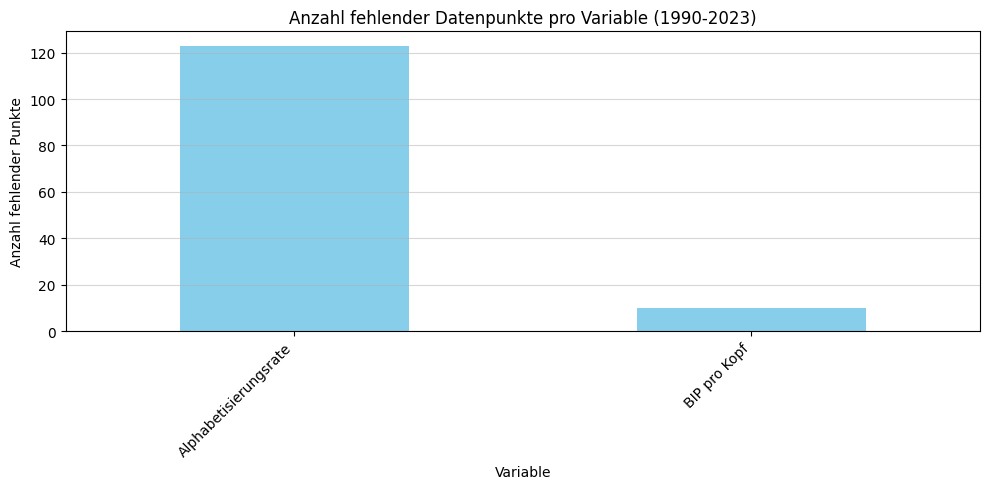

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 0. DATENKONFIGURATION UND VORBEREITUNG ---

# Dateipfad (Muss im selben Ordner wie das Skript liegen)
file_path = "literacy-rate-vs-gdp-per-capita.csv"

# Analyseparameter
target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq']
start_year = 1990
end_year = 2023

# Rohdaten-Spaltennamen
gdp_col_raw = 'GDP per capita, PPP (constant 2021 international $)'
literacy_col_raw = 'Literacy rate among adults'
pop_col_raw = 'Population (historical)'

# Daten laden und filtern
try:
    df_full = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Fehler: Datei '{file_path}' nicht gefunden. Bitte prüfen Sie den Pfad.")
    exit()

df_filtered = df_full[df_full['Entity'].isin(target_countries)].copy()
df_filtered['Year'] = pd.to_numeric(df_filtered['Year'], errors='coerce')

df_analysis = df_filtered[
    (df_filtered['Year'] >= start_year) & (df_filtered['Year'] <= end_year)
].copy()

# Spalten umbenennen (für die Analyse und Plots)
df_analysis.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    gdp_col_raw: 'BIP pro Kopf',
    literacy_col_raw: 'Alphabetisierungsrate',
    pop_col_raw: 'Bevölkerung'
}, inplace=True)


# --- 1. VARIABLENKLASSIFIZIERUNG UND KLASSENANALYSE ---

print("--- 1. Variablenanalyse (Kontinuierlich vs. Diskret) ---")
analysis_results = {}
discrete_info = {}

for col in ['Land', 'Jahr', 'BIP pro Kopf', 'Alphabetisierungsrate', 'Bevölkerung']:
    
    dtype = df_analysis[col].dtype
    n_unique = df_analysis[col].nunique()
    
    # Heuristik: Mehr als 15 eindeutige numerische Werte als kontinuierlich betrachtet
    if (dtype in ['int64', 'float64'] or col == 'Jahr') and n_unique > 15:
        variable_type = "kontinuierlich"
    else:
        variable_type = "diskret"
        
    print(f"Variable: {col} | Typ: {variable_type} | Einzigartige Werte: {n_unique}")
    
    if variable_type == "diskret":
        counts = df_analysis[col].value_counts().sort_index().to_dict()
        print(f"   -> Klassen ({n_unique}): {counts}")


# --- 2. ANZAHL DATENPUNKTE UND FEHLWERTE ---

print("\n--- 2. Fehlende Datenpunkte (Beschreibend und Grafisch) ---")
missing_counts = df_analysis.isnull().sum()
total_rows = len(df_analysis)
missing_percentage = (missing_counts / total_rows) * 100

missing_data_summary = pd.DataFrame({
    'Total': total_rows,
    'Vorhandene Punkte': df_analysis.count(),
    'Fehlende Punkte': missing_counts,
    'Fehlende (%)': missing_percentage.round(2)
})

# Grafische Darstellung der fehlenden Datenpunkte (fehlende Daten > 0)
plt.figure(figsize=(10, 5))
missing_counts_to_plot = missing_counts.drop(['Code', 'World regions according to OWID'], errors='ignore')
missing_counts_to_plot[missing_counts_to_plot > 0].plot(kind='bar', color='skyblue')
plt.title('Anzahl fehlender Datenpunkte pro Variable (1990-2023)')
plt.ylabel('Anzahl fehlender Punkte')
plt.xlabel('Variable')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('fehlende_daten_barchart.png')
print("Grafik 'fehlende_daten_barchart.png' wurde gespeichert.")

print("\nFehlende Datenpunkte (Tabelle):")
print(missing_data_summary.T.drop(['Code', 'World regions according to OWID'], axis=1, errors='ignore').to_markdown())


# --- 3. VERTEILUNG (HISTOGRAMM, BOXPLOT, SÄULENDIAGRAMM) ---

print("\n--- 3. Verteilung der zu untersuchenden Variablen (Grafiken) ---")

# a) Distributionen für kontinuierliche Variablen (BIP pro Kopf, Bevölkerung)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('Verteilung der kontinuierlichen Variablen (1990-2023)', fontsize=16)

# BIP pro Kopf
sns.histplot(df_analysis['BIP pro Kopf'].dropna(), kde=True, bins=15, ax=axes[0, 0])
axes[0, 0].set_title('Histogramm: BIP pro Kopf')
axes[0, 0].ticklabel_format(style='plain', axis='x')

sns.boxplot(x=df_analysis['BIP pro Kopf'].dropna(), ax=axes[1, 0])
axes[1, 0].set_title('Boxplot: BIP pro Kopf')
axes[1, 0].ticklabel_format(style='plain', axis='x')

# Bevölkerung
sns.histplot(df_analysis['Bevölkerung'].dropna(), kde=True, bins=15, ax=axes[0, 1])
axes[0, 1].set_title('Histogramm: Bevölkerung')
axes[0, 1].ticklabel_format(style='plain', axis='x')

sns.boxplot(x=df_analysis['Bevölkerung'].dropna(), ax=axes[1, 1])
axes[1, 1].set_title('Boxplot: Bevölkerung')
axes[1, 1].ticklabel_format(style='plain', axis='x')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('distribution_continuous.png')
print("Grafik 'distribution_continuous.png' wurde gespeichert.")


# b) Histogramm für Alphabetisierungsrate (sparsame Daten)
plt.figure(figsize=(10, 5))
sns.histplot(df_analysis['Alphabetisierungsrate'].dropna(), bins=10, kde=False)
plt.title('Histogramm: Alphabetisierungsrate (nur 13 Datenpunkte)')
plt.xlabel('Alphabetisierungsrate (%)')
plt.ylabel('Anzahl der Beobachtungen')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('distribution_literacy.png')
print("Grafik 'distribution_literacy.png' wurde gespeichert.")


# c) Säulendiagramm für diskrete Variable (Land)
plt.figure(figsize=(8, 5))
country_counts = df_analysis['Land'].value_counts()
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')
plt.title('Anzahl der Datenpunkte pro Land (1990-2023)')
plt.xlabel('Land')
plt.ylabel('Anzahl der Datenpunkte')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribution_country.png')
print("Grafik 'distribution_country.png' wurde gespeichert.")


# --- 4. ZUSAMMENHÄNGE (STREUUNGSDIAGRAMM, KORRELATIONSMATRIX) ---

print("\n--- 4. Zusammenhänge zwischen Variablen (Korrelation und Streuung) ---")
numerical_df = df_analysis[['Jahr', 'BIP pro Kopf', 'Alphabetisierungsrate', 'Bevölkerung']].copy()

# Korrelationsmatrix (nur vollständige Beobachtungen)
correlation_matrix = numerical_df.dropna().corr(method='pearson')

# Heatmap der Korrelation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar_kws={'label': 'Korrelationskoeffizient'})
plt.title('Korrelationsmatrix der Schlüsselvariablen')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('korrelationsmatrix.png')
print("Grafik 'korrelationsmatrix.png' wurde gespeichert.")

print("\nKorrelationsmatrix (Tabelle):")
print(correlation_matrix.to_markdown())


# Streuungsdiagramm: BIP pro Kopf vs. Alphabetisierungsrate (nach Land)
df_scatter = df_analysis.dropna(subset=['BIP pro Kopf', 'Alphabetisierungsrate', 'Bevölkerung'])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_scatter,
    x='BIP pro Kopf',
    y='Alphabetisierungsrate',
    hue='Land',
    size='Bevölkerung',
    sizes=(50, 500), 
    alpha=0.7,
    edgecolor='w'
)

plt.xscale('log')
plt.title('Zusammenhang: Alphabetisierungsrate vs. BIP pro Kopf')
plt.xlabel('BIP pro Kopf (PPP, Log-Skala)')
plt.ylabel('Alphabetisierungsrate (%)')
plt.grid(True, alpha=0.3)
plt.legend(title='Land / Bevölkerung', loc='lower right')
plt.tight_layout()
plt.savefig('streuungsdiagramm_bip_vs_literacy.png')
print("Grafik 'streuungsdiagramm_bip_vs_literacy.png' wurde gespeichert.")

# Die Plots werden in Ihrer Umgebung angezeigt/gespeichert, wenn Sie plt.show()
# am Ende des Skripts hinzufügen (im Notebook ist dies oft nicht nötig).
# plt.show()

In [55]:
import pandas as pd
import numpy as np

def generate_latest_country_summary(file_path):
    """
    Erstellt eine Tabelle mit den neuesten verfügbaren Daten (BIP, Analphabetisierungsrate,
    Bevölkerung) für Afghanistan, Sudan, Syrien und Irak.
    """
    
    # 1. Parameter definieren
    target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq']
    gdp_column = 'GDP per capita, PPP (constant 2021 international $)'
    literacy_column = 'Literacy rate among adults'
    pop_column = 'Population (historical)'

    # 2. Daten laden
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Fehler: Datei '{file_path}' nicht gefunden.")
        return None

    # 3. Analphabetisierungsrate (%) berechnen
    # (Der Code des Benutzers verwendet implizit die Illiteracy-Rate)
    df["Analphabetisierungsrate (%)"] = 100 - df[literacy_column]

    # 4. Spalten auswählen und umbenennen
    df_selected = df[['Entity', 'Year', 'Analphabetisierungsrate (%)', gdp_column, pop_column]].copy()
    df_selected.rename(columns={
        'Entity': 'Land',
        'Year': 'Jahr',
        gdp_column: 'BIP pro Kopf (PPP, $)',
        pop_column: 'Bevölkerung'
    }, inplace=True)

    # 5. Daten filtern (nur relevante Länder und Zeilen ohne fehlende Werte)
    df_dropna = df_selected[df_selected['Land'].isin(target_countries)].dropna(subset=['BIP pro Kopf (PPP, $)', 'Analphabetisierungsrate (%)', 'Bevölkerung'])

    # 6. Neuesten Wert pro Land finden (sortiert nach Jahr und nimmt den letzten)
    df_latest = (
        df_dropna.sort_values("Jahr")
        .groupby("Land", as_index=False)
        .tail(1)
    )

    # 7. Spaltenfinalisierung und Formatierung
    df_final = df_latest[['Land', 'Jahr', 'Analphabetisierungsrate (%)', 'BIP pro Kopf (PPP, $)', 'Bevölkerung']].copy()

    # Formatiere Zahlen
    df_final['Analphabetisierungsrate (%)'] = df_final['Analphabetisierungsrate (%)'].round(1)
    df_final['BIP pro Kopf (PPP, $)'] = df_final['BIP pro Kopf (PPP, $)'].round(0).astype(int)
    df_final['Bevölkerung'] = df_final['Bevölkerung'].round(0).astype(int)

    # 8. Tabelle exportieren (CSV)
    output_file_csv = 'vier_laender_zusammenfassung_ohne_gruppe.csv'
    df_final.to_csv(output_file_csv, index=False)

    print(f"Die Tabelle wurde als '{output_file_csv}' gespeichert und lautet:")
    print(df_final.to_markdown(index=False))
    
    return df_final

# Beispielhafte Ausführung (muss die Datei im aktuellen Verzeichnis haben)
# generate_latest_country_summary('literacy-rate-vs-gdp-per-capita.csv')

In [48]:
df_filtered = df[(df["Year"] >= 1985) & (df["Year"] <= 2025)]
df_filtered.head()

,Entity,Code,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical),World regions according to OWID
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN
5,Afghanistan,AFG,2001,NaN,1454.1108,20284303.0,NaN


## 3. Statistik der Roh-Daten (Analyse im Long-Format)

über die einzelnen Spalten kann folgendes ausgesagt werden:
- Die Spalte *Gebiete* enthält 261 verschieden Gebiete
- Die Spalte *Codes* enthält 239 verschiedene Codes
- Es sind Daten zwischen 1543 and 2021 vorhanden. Ab dem Jahr 1950 sind die Daten komplett
- Die Lebenserwartung streut zwischen 12 und 86.5 Jahren

In [32]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59712 entries, 0 to 59711
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               59712 non-null  object 
 1   Code                                                 55519 non-null  object 
 2   Year                                                 59712 non-null  int64  
 3   Literacy rate among adults                           1725 non-null   float64
 4   GDP per capita, PPP (constant 2021 international $)  7236 non-null   float64
 5   Population (historical)                              58824 non-null  float64
 6   World regions according to OWID                      272 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 3.2+ MB


Index(['Entity', 'Code', 'Year', 'Literacy rate among adults',
       'GDP per capita, PPP (constant 2021 international $)',
       'Population (historical)', 'World regions according to OWID'],
      dtype='object')

### 3.1 Analyse Gebiete

In [49]:
print('Anzahl verschiedener Gebiete: ', len(df['Entity'].unique()))

Anzahl verschiedener Gebiete:  310


In [50]:
# Anzahl Datenpunkte pro Gebiet
df['Entity'].value_counts()

Entity
Zimbabwe                                        262
Zambia                                          262
United Arab Emirates                            262
Ukraine                                         262
Uganda                                          262
                                               ... 
Duchy of Parma and Piacenza                       1
British Indian Ocean Territory                    1
Sudan (former)                                    1
South Georgia and the South Sandwich Islands      1
Austria-Hungary                                   1
Name: count, Length: 310, dtype: int64

<Axes: title={'center': 'Anzahl Datenpunkte pro Gebiet'}, xlabel='Entity', ylabel='Anzahl Datenpunkte'>

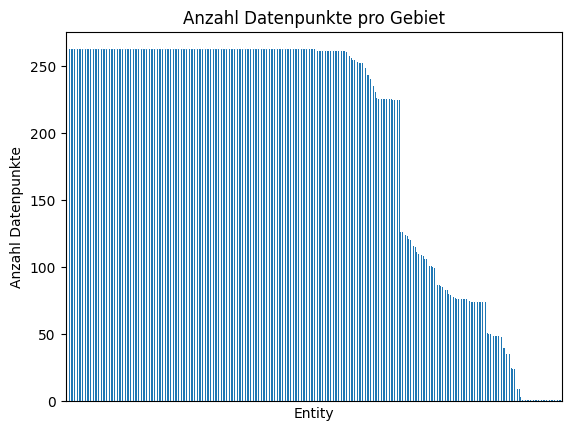

In [35]:
df['Entity'].value_counts().plot(kind='bar', 
                                 xticks=[],     # disable labels on x-axis
                                 ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Gebiet')

### 3.2 Analyse Codes

In [36]:
print('Anzahl verschiedener Codes: ', len(df['Code'].unique()))

Anzahl verschiedener Codes:  261


In [37]:
# Anzahl Datenpunkte pro Gebiet
df['Code'].value_counts()

Code
ZWE    262
ZMB    262
GBR    262
ARE    262
UKR    262
      ... 
PCN      1
SGS      1
IOT      1
CCK      1
CXR      1
Name: count, Length: 260, dtype: int64

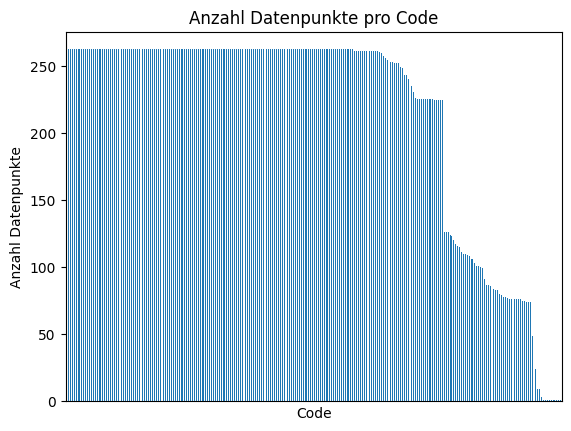

In [38]:
df['Code'].value_counts().plot(kind='bar',xticks=[], ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Code');

### 3.3 Analyse Jahr

### 3.4 Analyse Lebenserwartung

In [39]:
df.describe()

,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical)
count,59712.000000,1725.000000,7236.000000,5.882400e+04
mean,1619.756314,77.336331,21729.221482,5.088952e+07
std,1390.459662,19.335627,23785.629715,3.003927e+08
min,-10000.000000,9.000000,510.822800,1.000000e+00
25%,1834.000000,64.492390,4372.770950,1.479938e+05
50%,1904.000000,82.157580,12710.775000,1.409324e+06
75%,1970.000000,94.000000,32508.406000,6.787372e+06
max,2024.000000,100.000000,174339.000000,8.091735e+09


In [40]:
g = df['Lebenserwartung'].plot(kind='hist', bins=20, title='Histogramm der Lebenserwartung', 
                           xlabel='Lebenserwartung', ylabel='Anzahl Datenpunkte')
mean = df['Lebenserwartung'].mean()
g.axvline(x=df['Lebenserwartung'].mean(), color='red',label=f'Mittelwert = {mean:.2f}')  # rote Linie bei Mittelwert

median = df['Lebenserwartung'].median()
g.axvline(x=df['Lebenserwartung'].median(), color='orange',label=  f'Median = {median:.2f}')  # orange Linie bei Median

g.legend()




KeyError: 'Lebenserwartung'

## 4. Analyse 

### Vorgehen

### Beobachtungen
- Afrikanische Länder sind an der Spitze in der Zunahme der Lebenserwartung. Eine Zunahme der Lebenserwartung von mehr als 5 Jahren haben: Uganda, Tanzania, Malawi, Zimbabwe, Lesotho, Swasiland
- Eine Reduktion der Lebenserwartung von mehr als 4 Jahren haben: Saint Vincent and the Grenadines, Mexiko, Kuba, Oman


### Interpretation

Corona führte bei allen Ländern zu einer Reduktion der Lebenserwartung (siehe Plot)

Länder (in Afrika) mit starker Zunahme der Lebensqualität:
- Bei den afrikanischen Ländern stieg die Lebenserwartung in den letzten Jahren sehr stark, da die Lebenserwartung sehr tief war. Zudem ist der Effekt von Corona auf die Lebenserwartung in den afrikanischen Ländern eher kleiner weil die Bevölkerung jünger ist
- Bei einigen afrikanischen Ländern hat sich die Lebenserwartung zwischen 1990 und 2000 stark verringert wegen HIV. Siehe Beispielsweise: https://life4me.plus/pl/news/life-expectancy-in-zimbabwe-shoots-up-hiv-infection-drop/


Länder mit einer starken Reduktion der Lebensqualität:
- Hier war die Lebenserwartung in den Jahren vor Corona konstant. Corona führte dann zu einer Reduktion der Lebenserwartung


### Berechnungen

### Visualisierung

In [ ]:
color_dict = {
    'Saint Vincent and the Grenadines': 'blue',
    'Mexico': 'cyan',
    'Cuba': 'lightgreen',
    'Oman': 'green',
    'Tanzania': 'red',
    'Sierra Leone': 'orange',
    'Malawi': 'yellow',
    'Zimbabwe': 'brown',
    'Lesotho': 'pink',
    'Eswatini': 'purple'
}

for gebiet in Gebiets_liste:
    diff = diffs[gebiet]
    g = df_pivot.loc[gebiet].plot(title='Lebenserwartungen', xlabel='Jahr', ylabel=f'Lebenserwartung', legend=True,
                                  label=f'{gebiet} - Diff. 2021-2011: {diff:.2f}', # für die Legende
                                  xlim=[1980,2025], ylim=[0,80],   # x- und y-Achsen begrenzen
                                  color=color_dict[gebiet],        # Farbe aus color_dict
                                  figsize=(7,7))                   # Grösse des Plots

# Covid Pandemie    
g.axvline(x=2020, color='black', linestyle='--') 
g.text(2020.5, 37, 'Covid')  

# HIV Pandemie
g.axvline(x=2005, color='black', linestyle='--')  
g.text(2005.5, 37, 'HIV');

NameError: name 'Gebiets_liste' is not defined